In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('Gaming_Academic_Performance.csv')

from sklearn.model_selection import train_test_split

bins= [-float("inf"), 59, 69, 79, 89, float("inf")]
labels = ['F', 'D', 'C', 'B', 'A']

dataset["letter_grade"] = pd.cut(dataset["grades"], bins=bins, labels=labels)

train_set, test_set = train_test_split(dataset, test_size=.2, 
                                       stratify=dataset["letter_grade"], 
                                       random_state=42)

In [2]:
import os
os.makedirs('figures', exist_ok=True)

In [3]:
train_set, val_set = train_test_split(train_set, test_size=.2,
                                      stratify=train_set["letter_grade"],
                                      random_state=42)

train_set.drop(columns=["student_id", "age", "social_activity", "gaming_genre", "letter_grade", "gender"], inplace=True)
val_set.drop(columns=["student_id", "age", "social_activity", "gaming_genre", "letter_grade", "gender"], inplace=True)
test_set.drop(columns=["student_id", "age", "social_activity", "gaming_genre", "letter_grade", "gender"], inplace=True)
#determined in the previous notebook to not be valueable


In [4]:
train_set

,gaming_hours,study_hours,sleep_hours,attendance,device_usage,reaction_time_ms,addiction_score,stress_level,grades
1278,2.01,8.42,7.42,65.89,7.34,278.85,7.16,Medium,95.920000
4276,3.33,4.97,7.10,79.80,8.69,276.74,9.50,Medium,67.640000
99,4.28,3.32,5.06,74.11,9.68,253.12,11.55,Medium,40.980000
6320,3.87,2.93,5.41,77.55,8.96,284.48,13.29,Medium,49.590000
4406,1.76,1.86,6.43,77.47,3.72,303.59,10.40,Medium,64.560000
...,...,...,...,...,...,...,...,...,...
714,2.38,7.97,7.92,71.48,6.97,297.94,8.24,Medium,99.940000
7439,3.45,9.93,4.31,96.83,8.13,284.43,3.58,High,100.000000
7474,2.62,7.79,4.95,96.58,4.84,297.12,3.25,High,90.950000
3619,6.90,5.19,5.11,78.63,7.92,242.57,16.98,Low,41.380000


In [5]:
x_train, y_train = train_set.drop(columns=["grades"]), np.ravel(train_set[["grades"]])
x_validation, y_validation = val_set.drop(columns=["grades"]), np.ravel(val_set[["grades"]])
x_test, y_test = test_set.drop(columns=["grades"]), np.ravel(test_set[["grades"]])


In [6]:
x_train

,gaming_hours,study_hours,sleep_hours,attendance,device_usage,reaction_time_ms,addiction_score,stress_level
1278,2.01,8.42,7.42,65.89,7.34,278.85,7.16,Medium
4276,3.33,4.97,7.10,79.80,8.69,276.74,9.50,Medium
99,4.28,3.32,5.06,74.11,9.68,253.12,11.55,Medium
6320,3.87,2.93,5.41,77.55,8.96,284.48,13.29,Medium
4406,1.76,1.86,6.43,77.47,3.72,303.59,10.40,Medium
...,...,...,...,...,...,...,...,...
714,2.38,7.97,7.92,71.48,6.97,297.94,8.24,Medium
7439,3.45,9.93,4.31,96.83,8.13,284.43,3.58,High
7474,2.62,7.79,4.95,96.58,4.84,297.12,3.25,High
3619,6.90,5.19,5.11,78.63,7.92,242.57,16.98,Low


In [7]:
y_train

array([95.92      , 67.64      , 40.98      , ..., 90.95      ,
       41.38      , 73.71950646], shape=(5120,))

In [8]:
x_train["stress_level"] = x_train["stress_level"].astype("object")
x_test["stress_level"] = x_test["stress_level"].astype("object")

In [9]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer

#Preprocessing Pipeline 1: Standard sclaing and conversion of categorical variables
_pipeline_numeric = make_pipeline(StandardScaler())
_pipeline_categorical = make_pipeline(
    OrdinalEncoder(categories=[["Low", "Medium", "High"]]),
    FunctionTransformer(func=lambda X: X - 1, feature_names_out='one-to-one') #nomralize them to the same range of our standard scaler.
    )

numeric_cols = x_train.select_dtypes(include='number').columns
cat_cols = ["stress_level"]

preprocessing_standard = ColumnTransformer([
    ("num", _pipeline_numeric, numeric_cols),
    ("cat", _pipeline_categorical, cat_cols)
])

#Preprocessing pipeline 2: Create a composite variable for highly correlated features
def _create_composite(X):
    z = X * [1, 1, -1, 1] #flips reaction_time_ms (index 2)
    return z.mean(axis=1).reshape(-1, 1)

def _composite_name(function_transformer, feature_names_in):
    return ['gamer_score']

_pipeline_composite = make_pipeline(StandardScaler(), FunctionTransformer(func=_create_composite, feature_names_out=_composite_name))

correlated_cols = ["gaming_hours", "device_usage", "reaction_time_ms", "addiction_score"]
numeric_non_correlated = [x for x in numeric_cols if x not in correlated_cols]

preprocessing_composite = ColumnTransformer([
    ("composite", _pipeline_composite, correlated_cols),
    ("num", _pipeline_numeric, numeric_non_correlated),
    ("cat", _pipeline_categorical, cat_cols)
])

#Pipeline 3: Experiments with polynomial feature creates to see if interactions help. Explodes feature space

_pipeline_numeric_poly = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=False, include_bias=False),
)

preprocessing_poly = ColumnTransformer([
    ("num_poly", _pipeline_numeric_poly, numeric_cols),
    ("cat", _pipeline_categorical, cat_cols),
])


In [10]:
#Screening of some linear models
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

sgd_pipe = Pipeline([
    ("preprocessor", preprocessing_standard),
    ("model", SGDRegressor(random_state=42, max_iter=5000, early_stopping=True))
])

In [ ]:
import sklearn, pandas, numpy
print(f"sklearn: {sklearn.__version__}")
print(f"pandas:  {pandas.__version__}")
print(f"numpy:   {numpy.__version__}")

sklearn: 1.8.0
pandas:  3.0.2
numpy:   2.4.4


In [12]:
param_grid = [
    {
        "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
        "model__loss": ["squared_error", "huber", "epsilon_insensitive"],
        "model__penalty": ["l1", "l2", "elasticnet", None],
        "model__alpha": [1e-4, 1e-3], 
        "model__learning_rate": ["adaptive"],
        "model__eta0": [0.01],
    }
]

grid = GridSearchCV(
    sgd_pipe,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__alpha': [0.0001, 0.001], 'model__eta0': [0.01], 'model__learning_rate': ['adaptive'], 'model__loss': ['squared_error', 'huber', ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

Chosen regular squared error loss with l1 penalty using a poly preprocessing.

Training time is near instantanious and guesses grade with an error of ~5%.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = grid.best_estimator_

# Predictions
y_va_pred = best_model.predict(x_validation)

# Metrics on the validation set
mae = mean_absolute_error(y_validation, y_va_pred)
mse = mean_squared_error(y_validation, y_va_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_validation, y_va_pred)

print(f"Best params:     {grid.best_params_}")
print(f"Best CV MAE:     {-grid.best_score_:.4f}")
print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Best params:     {'model__alpha': 0.001, 'model__eta0': 0.01, 'model__learning_rate': 'adaptive', 'model__loss': 'squared_error', 'model__penalty': 'l1', 'preprocessor': ColumnTransformer(transformers=[('num_poly',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler()),
                                                 ('polynomialfeatures',
                                                  PolynomialFeatures(include_bias=False))]),
                                 Index(['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
       'device_usage', 'reaction_time_ms', 'addiction_score'],
      dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                  

~5% error on average for a grade prediction. That means an A could be a B+ and an F could be a D. Not perfect but not horrible too.

Testing out Support Vector Regressors now.

In [15]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV #Doing randomized search for training efficiency
from scipy.stats import uniform, loguniform


svr_pipe = Pipeline([
    ("preprocessor", preprocessing_standard),  # placeholder
    ("model", SVR(verbose=1, cache_size=500, max_iter=100_000)),
])

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV #Doing randomized search for training efficiency
from scipy.stats import uniform, loguniform


svr_pipe = Pipeline([
    ("preprocessor", preprocessing_standard),  # placeholder
    ("model", SVR(verbose=1, cache_size=500, max_iter=100_000)),
])

from scipy.stats import loguniform, uniform

param_distributions = [
    # RBF kernel
    {
        "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
        "model__kernel": ["rbf"],
        "model__C": loguniform(1e-2, 1e3),
        "model__gamma": loguniform(1e-4, 1e1),
        "model__epsilon": loguniform(1e-3, 1e0),
        "model__tol": loguniform(1e-4, 1e-2),
    },
    # Linear kernel
    {
        "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
        "model__kernel": ["linear"],
        "model__C": loguniform(1e-2, 1e3),
        "model__epsilon": loguniform(1e-3, 1e0),
        "model__tol": loguniform(1e-4, 1e-2),
    },
    # Polynomial kernel
    {
        "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
        "model__kernel": ["poly"],
        "model__degree": [2, 3, 4],                    
        "model__C": loguniform(1e-2, 1e3),
        "model__gamma": loguniform(1e-4, 1e1),
        "model__coef0": uniform(0, 5),
        "model__epsilon": loguniform(1e-3, 1e0),
        "model__tol": loguniform(1e-4, 1e-2),
    },
    # Sigmoid kernel
    {
        "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
        "model__kernel": ["sigmoid"],
        "model__C": loguniform(1e-2, 1e3),
        "model__gamma": loguniform(1e-4, 1e1),
        "model__coef0": uniform(-1, 2),
        "model__epsilon": loguniform(1e-3, 1e0),
        "model__tol": loguniform(1e-4, 1e-2),
    },
]

random_search = RandomizedSearchCV(
    svr_pipe,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True,
)

In [17]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LibSVM]

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model__C': <scipy.stats....0024A2DE1FFE0>, 'model__epsilon': <scipy.stats....0024A2E154DD0>, 'model__gamma': <scipy.stats....0024A2E19F290>, 'model__kernel': ['rbf'], ...}, {'model__C': <scipy.stats....0024A2E14F9B0>, 'model__epsilon': <scipy.stats....0024A2E19D370>, 'model__kernel': ['linear'], 'model__tol': <scipy.stats....0024A2E14EF30>, ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFol

In [18]:
best_model = random_search.best_estimator_

# Predictions
y_va_pred = best_model.predict(x_validation)

# Metrics on the validation set
mae = mean_absolute_error(y_validation, y_va_pred)
mse = mean_squared_error(y_validation, y_va_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_validation, y_va_pred)

print(f"Best params:     {random_search.best_params_}")
print(f"Best CV MAE:     {-random_search.best_score_:.4f}")
print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Best params:     {'model__C': np.float64(156.5552046899741), 'model__epsilon': np.float64(0.38125351372349975), 'model__gamma': np.float64(0.0017834330171278882), 'model__kernel': 'rbf', 'model__tol': np.float64(0.00011958300672269896), 'preprocessor': ColumnTransformer(transformers=[('num_poly',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler()),
                                                 ('polynomialfeatures',
                                                  PolynomialFeatures(include_bias=False))]),
                                 Index(['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
       'device_usage', 'reaction_time_ms', 'addiction_score'],
      dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Low',
                       

Dropped down to 4.6

In [19]:
dataset = pd.read_csv('Gaming_Academic_Performance.csv')

bins= [-float("inf"), 59, 69, 79, 89, float("inf")]
labels = ['F', 'D', 'C', 'B', 'A']

dataset["letter_grade"] = pd.cut(dataset["grades"], bins=bins, labels=labels)

train_set_noise, test_set_noise = train_test_split(dataset, test_size=.2, 
                                       stratify=dataset["letter_grade"], 
                                       random_state=42)

In [20]:
train_set_noise, val_set_noise = train_test_split(dataset, test_size=.2, 
                                       stratify=dataset["letter_grade"], 
                                       random_state=42)

In [21]:
tr_x_noise, tr_y_noise = train_set_noise.drop(columns=["letter_grade", "grades"]), train_set_noise[["grades"]]
va_x_noise, va_y_noise = val_set_noise.drop(columns=["letter_grade", "grades"]), val_set_noise[["grades"]]
te_x_noise, te_y_noise = test_set_noise.drop(columns=["letter_grade", "grades"]), test_set_noise[["grades"]]

In [22]:
tr_x_noise.drop(columns=["student_id"], inplace=True) #almost certainly useless

In [23]:
va_x_noise.drop(columns=["student_id"], inplace=True)
te_x_noise.drop(columns=["student_id"], inplace=True)

In [24]:
from sklearn.preprocessing import OneHotEncoder

numeric_cols = tr_x_noise.select_dtypes(include='number').columns
cat_cols = ["stress_level"]
one_hot_cols = ["gender", "gaming_genre"]

_pipeline_one_hot = make_pipeline(OneHotEncoder())

preprocessing_raw = ColumnTransformer([
    ("num_poly", _pipeline_numeric_poly, numeric_cols),
    ("cat", _pipeline_categorical, cat_cols),
    ("onehot", _pipeline_one_hot, one_hot_cols)
])


In [25]:


best_svr = SVR(
    C=156.55, 
    epsilon=0.38, 
    gamma=0.001783, 
    kernel='rbf', 
    tol=0.0001195,
    verbose=1,
    cache_size=500
)

best_pipe = Pipeline([
    ("prep", preprocessing_raw),
    ("model", best_svr)
])

best_pipe.fit(tr_x_noise, tr_y_noise)

[LibSVM]

c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_poly', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [26]:
y_va_pred = best_pipe.predict(va_x_noise)

# Metrics on the validation set
mae = mean_absolute_error(va_y_noise, y_va_pred)
mse = mean_squared_error(va_y_noise, y_va_pred)
rmse = np.sqrt(mse)
r2 = r2_score(va_y_noise, y_va_pred)

print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Validation MAE:  4.5967
Validation RMSE: 5.8085
Validation R²:   0.9320


In [27]:
from sklearn.model_selection import cross_val_score

# Cross-validation for best_pipe on tr_x_noise, tr_y_noise
cv_scores_best_pipe = cross_val_score(best_pipe, tr_x_noise, tr_y_noise, cv=3, scoring='neg_mean_absolute_error')
print("CV scores for best_pipe:", -cv_scores_best_pipe)
print("Mean CV MAE for best_pipe:", -cv_scores_best_pipe.mean())

# Cross-validation for random_search.best_estimator_ on x_train, y_train
cv_scores_random = cross_val_score(random_search.best_estimator_, x_train, y_train, cv=3, scoring='neg_mean_absolute_error')
print("CV scores for random_search.best_estimator_:", -cv_scores_random)
print("Mean CV MAE for random_search.best_estimator_:", -cv_scores_random.mean())

# Cross-validation for grid.best_estimator_ on x_train, y_train
cv_scores_grid = cross_val_score(grid.best_estimator_, x_train, y_train, cv=3, scoring='neg_mean_absolute_error')
print("CV scores for grid.best_estimator_:", -cv_scores_grid)
print("Mean CV MAE for grid.best_estimator_:", -cv_scores_grid.mean())

[LibSVM]

c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LibSVM]

c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LibSVM]CV scores for best_pipe: [4.6361741  4.64632089 4.67487866]
Mean CV MAE for best_pipe: 4.652457883512013
[LibSVM][LibSVM][LibSVM]CV scores for random_search.best_estimator_: [4.64854493 4.57064081 4.61393318]
Mean CV MAE for random_search.best_estimator_: 4.611039639590328
CV scores for grid.best_estimator_: [4.85776696 4.849005   4.88785459]
Mean CV MAE for grid.best_estimator_: 4.864875516972362


Adding in the full dataset doesn't necessarily net an improvement

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_pipe = Pipeline([
    ("preprocessor", preprocessing_standard), 
    ("model", HistGradientBoostingRegressor(random_state=42)),
])

hgb_distributions = {
    "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_iter": [200, 500, 1000],
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": loguniform(1e-4, 1e1),
    "model__max_leaf_nodes": [15, 31, 63, 127],
}

random_search_hist=RandomizedSearchCV(
    hgb_pipe,
    param_distributions=hgb_distributions,
    scoring="neg_mean_absolute_error",
    n_iter=100,
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True,
)

random_search_hist.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l2_regularization': <scipy.stats....0024A2E36B440>, 'model__learning_rate': <scipy.stats....0024A2E34BBC0>, 'model__max_depth': [None, 3, ...], 'model__max_iter': [200, 500, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:

In [29]:
best_model = random_search_hist.best_estimator_

y_va_pred = best_model.predict(x_validation)

# Metrics on the validation set
mae = mean_absolute_error(y_validation, y_va_pred)
mse = mean_squared_error(y_validation, y_va_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_validation, y_va_pred)

print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Validation MAE:  4.4921
Validation RMSE: 5.7696
Validation R²:   0.9348


Even Better Results.

In [30]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from scipy.stats import loguniform
import time

searches = {
    "KernelRidge": {
        "pipe": Pipeline([
            ("preprocessor", preprocessing_standard),
            ("model", KernelRidge()),
        ]),
        "distributions": {
            "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
            "model__kernel": ["rbf"],
            "model__alpha": loguniform(1e-4, 1e1),
            "model__gamma": loguniform(1e-4, 1e1),
        },
        "n_iter": 60,
    },
    "RandomForest": {
        "pipe": Pipeline([
            ("preprocessor", preprocessing_standard),
            ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ]),
        "distributions": {
            "preprocessor": [preprocessing_standard, preprocessing_composite],
            "model__n_estimators": [200, 500, 1000],
            "model__max_depth": [None, 5, 10, 20, 30],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.5, 1.0],
        },
        "n_iter": 60,
    },
    "MLP": {
        "pipe": Pipeline([
            ("preprocessor", preprocessing_standard),
            ("model", MLPRegressor(random_state=42, max_iter=500, early_stopping=True)),
        ]),
        "distributions": {
            "preprocessor": [preprocessing_standard, preprocessing_composite],
            "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (256, 128, 64)],
            "model__activation": ["relu", "tanh"],
            "model__alpha": loguniform(1e-5, 1e-1),
            "model__learning_rate_init": loguniform(1e-4, 1e-2),
        },
        "n_iter": 60,
    },
}

results = []
fitted_searches = {}

for name, cfg in searches.items():
    print(f"\n{'='*60}\nRunning {name}...\n{'='*60}")
    t0 = time.time()

    search = RandomizedSearchCV(
        cfg["pipe"],
        param_distributions=cfg["distributions"],
        n_iter=cfg["n_iter"],
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True,
    )
    search.fit(x_train, y_train)
    elapsed = time.time() - t0
    fitted_searches[name] = search

    # Evaluate on validation set
    y_va_pred = search.best_estimator_.predict(x_validation)
    mae = mean_absolute_error(y_validation, y_va_pred)
    rmse = np.sqrt(mean_squared_error(y_validation, y_va_pred))
    r2 = r2_score(y_validation, y_va_pred)

    results.append({
        "Model": name,
        "CV MAE": -search.best_score_,
        "Val MAE": mae,
        "Val RMSE": rmse,
        "Val R²": r2,
        "Time (s)": elapsed,
    })

    print(f"\n{name} done in {elapsed:.1f}s")
    print(f"  Best params: {search.best_params_}")
    print(f"  CV MAE:  {-search.best_score_:.4f}")
    print(f"  Val MAE: {mae:.4f}")


print(f"\n{'='*60}\nFinal Comparison\n{'='*60}")
results_df = pd.DataFrame(results).sort_values("Val MAE")
print(results_df.to_string(index=False))


Running KernelRidge...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

KernelRidge done in 196.6s
  Best params: {'model__alpha': np.float64(0.001289849537718266), 'model__gamma': np.float64(0.0003974905761171869), 'model__kernel': 'rbf', 'preprocessor': ColumnTransformer(transformers=[('num_poly',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler()),
                                                 ('polynomialfeatures',
                                                  PolynomialFeatures(include_bias=False))]),
                                 Index(['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
       'device_usage', 'reaction_time_ms', 'addiction_score'],
      dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Low',
     

Biggest Takeaway: Polynomial + RBF Kernel on data with a linear fitter is performing very well.

In [31]:
from sklearn.neighbors import KNeighborsRegressor

knn_pipe = Pipeline([
    ("preprocessor", preprocessing_standard),
    ("model", KNeighborsRegressor(n_jobs=-1)),
])

knn_distributions = {
    "preprocessor": [preprocessing_standard, preprocessing_composite, preprocessing_poly],
    "model__n_neighbors": [3, 5, 10, 15, 25, 50, 100],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

print("Running KNN search...")
t0 = time.time()
knn_search = RandomizedSearchCV(
    knn_pipe,
    param_distributions=knn_distributions,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
)
knn_search.fit(x_train, y_train)
print(f"KNN search done in {time.time() - t0:.1f}s\n")


def get_metrics(model, x_va, y_va):
    pred = model.predict(x_va)
    return {
        "Val MAE": mean_absolute_error(y_va, pred),
        "Val RMSE": np.sqrt(mean_squared_error(y_va, pred)),
        "Val R²": r2_score(y_va, pred),
    }

rows = [
    {
        "Model": "SGD (linear)",
        "CV MAE": -grid.best_score_,
        **get_metrics(grid.best_estimator_, x_validation, y_validation),
    },
    {
        "Model": "SVR",
        "CV MAE": -random_search.best_score_,
        **get_metrics(random_search.best_estimator_, x_validation, y_validation),
    },
    {
        "Model": "HistGradientBoosting",
        "CV MAE": -random_search_hist.best_score_,
        **get_metrics(random_search_hist.best_estimator_, x_validation, y_validation),
    },
    {
        "Model": "KNN",
        "CV MAE": -knn_search.best_score_,
        **get_metrics(knn_search.best_estimator_, x_validation, y_validation),
    },
]

for name, search in fitted_searches.items():
    rows.append({
        "Model": name,
        "CV MAE": -search.best_score_,
        **get_metrics(search.best_estimator_, x_validation, y_validation),
    })

summary_table = pd.DataFrame(rows).sort_values("Val MAE").reset_index(drop=True)

print("Model comparison (sorted by validation MAE)")
print()
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 200):
    print(summary_table[["Model", "CV MAE", "Val MAE", "Val RMSE", "Val R²"]].to_string(index=False))

Running KNN search...
KNN search done in 1.8s

Model comparison (sorted by validation MAE)

               Model  CV MAE  Val MAE  Val RMSE  Val R²
HistGradientBoosting  4.5404   4.4921    5.7696  0.9348
                 MLP  4.5732   4.5729    5.8267  0.9335
         KernelRidge  4.5890   4.5846    5.8274  0.9334
                 SVR  4.5746   4.6257    5.8964  0.9319
        RandomForest  4.7543   4.6896    6.0056  0.9293
        SGD (linear)  4.8531   4.7870    6.1035  0.9270
                 KNN  5.2642   5.1707    6.5942  0.9148


The Key Takeaways: GradientBoosting performed best, and KernelRidge and SVR with poly + rbf kernel are performing second best. Lets build a framework to try to take advantage of all of these strengths.

Idea: Nystroem approximation. Using Nystroem approximation we can essentially build features 'as if' we were using the rbf kernel without actually using them.

How this works to my understanding: Nystroem uses a specific kernel then samples a set of different enough points from that kernel. for each point it takes a similarity score of the kernel representation of that feature as well as the point in the kernel space and uses that for the features.

In [32]:
from sklearn.kernel_approximation import Nystroem

nystroem_pipe = Pipeline([
    ("poly_prep", preprocessing_poly), #I think we've settled on this being the best kernel
    ("nystroem", Nystroem(kernel="rbf", n_components=300, random_state=42)),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

param_dist = {
    "nystroem__kernel": ["rbf", "poly"], #experiment with stacking poly on poly
    "nystroem__gamma": loguniform(1e-4, 1e1), #controls distance scaling for simularity measure
    "nystroem__n_components": [100, 300, 500], #number of landmark points
    "model__learning_rate": loguniform(0.01, 0.3), #shrinkage
    "model__max_iter": [200, 500], #number of trees
    "model__max_leaf_nodes": [15, 31, 63] ,#max number of leaf nodes for each tree
    "model__min_samples_leaf": [10, 20, 50], #min number of samples to not split
    "model__l2_regularization": loguniform(1e-4, 1e1)
}

rs_nyo = RandomizedSearchCV(
    nystroem_pipe,
    param_distributions=param_dist,
    cv=5,
    n_iter=100,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    refit=True,
    verbose=1,
    random_state=42
)


In [33]:
rs_nyo.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l2_regularization': <scipy.stats....0024A3ADB5610>, 'model__learning_rate': <scipy.stats....0024A3ADB6A20>, 'model__max_iter': [200, 500], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`

Polynomial Kernel


In [34]:
best_nyo = rs_nyo.best_estimator_

y_va_pred = best_nyo.predict(x_validation)

# Metrics on the validation set
mae = mean_absolute_error(y_validation, y_va_pred)
mse = mean_squared_error(y_validation, y_va_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_validation, y_va_pred)

print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Validation MAE:  4.8367
Validation RMSE: 6.1695
Validation R²:   0.9254


Notes: opted for double polynomial kernel over rbf. MAE is higher (performed worse). Let's use this information to build our final model.

Final Model Design Idea: Stacking classifier of our best models. Use our strongest models best predictions and stack them with a meta learner to create our strongest predictor.

In [35]:
best_hbg = random_search_hist.best_estimator_
best_mlp = fitted_searches["MLP"].best_estimator_
best_kr = fitted_searches["KernelRidge"].best_estimator_
best_svr = random_search.best_estimator_
best_rf = fitted_searches["RandomForest"].best_estimator_
best_sgd = grid.best_estimator_
best_knn = knn_search.best_estimator_

preds = pd.DataFrame({
    "hgb": best_hbg.predict(x_validation),
    "mlp": best_mlp.predict(x_validation),
    "kr": best_kr.predict(x_validation),
    "svr": best_svr.predict(x_validation),
    "rf": best_rf.predict(x_validation),
    "sgd": best_sgd.predict(x_validation),
    "knn": best_sgd.predict(x_validation)
})

print(preds.corr())


          hgb       mlp        kr       svr        rf       sgd       knn
hgb  1.000000  0.994118  0.994614  0.994201  0.994813  0.990808  0.990808
mlp  0.994118  1.000000  0.997536  0.997452  0.992134  0.993681  0.993681
kr   0.994614  0.997536  1.000000  0.999470  0.992010  0.995774  0.995774
svr  0.994201  0.997452  0.999470  1.000000  0.991699  0.995381  0.995381
rf   0.994813  0.992134  0.992010  0.991699  1.000000  0.988118  0.988118
sgd  0.990808  0.993681  0.995774  0.995381  0.988118  1.000000  1.000000
knn  0.990808  0.993681  0.995774  0.995381  0.988118  1.000000  1.000000


After seeing how correlated all our predictions are I would say we are roughly at the ceiling for this dataset. Stacking won't help and all models have essentially learned the same key things. The data set is easy to work with and given consistently good signals to all models. At this point any improvements would be needlessly complex for only a marginal gain, so let us move forward with HGB as our final model

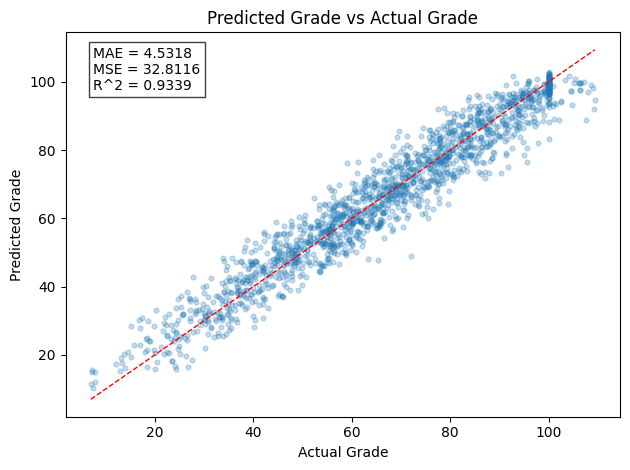

In [36]:
import matplotlib.pyplot as plt

y_pred = best_hbg.predict(x_test)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_test.max())]

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


plt.scatter(y_test, y_pred, alpha=0.25, s=12)
plt.plot(lims, lims, "r--", lw=1)
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.text(0.05, 0.85,
        f"MAE = {mae:.4f}\nMSE = {mse:.4f}\nR^2 = {r2:.4f}",
        transform=plt.gca().transAxes,
        bbox={'boxstyle':'square', 'facecolor':'white', 'alpha':0.75})
plt.title("Predicted Grade vs Actual Grade")
plt.tight_layout()
plt.savefig('figures/predicted_vs_actual_grade.png', dpi=150, bbox_inches='tight')
plt.show()

predicts the true grade with within on average +- 4.5% of the grade. our predictions seem to match our actual grade the whole way through. Maybe just ever so slightly optimistic in the <20 rand and pessimistic in the >20 range.

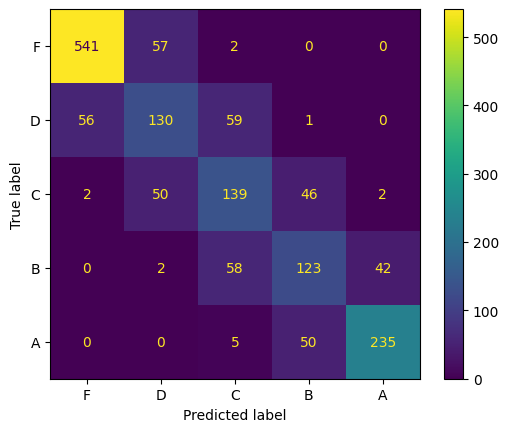

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true_grade_letter = pd.cut(y_test, bins=bins, labels=labels)
predicted_grade_letter = pd.cut(y_pred, bins=bins, labels=labels)

cm = confusion_matrix(true_grade_letter, predicted_grade_letter, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot()
plt.savefig('figures/confusion_matrix_grade.png', dpi=150, bbox_inches='tight')
plt.show()

Essentially always guesses failing students correctly. and guesses all the other letter grades within one letter grade of the true letter grade essentially all the time.

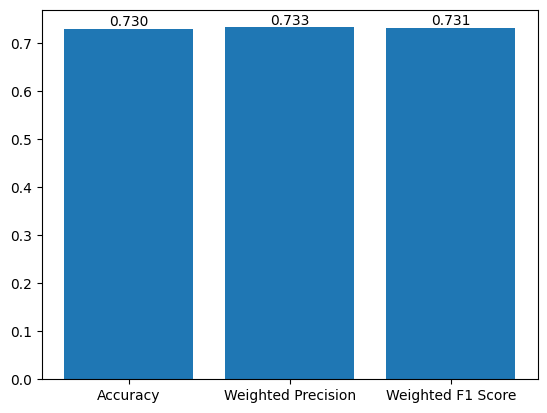

In [38]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

acc = accuracy_score(true_grade_letter, predicted_grade_letter)
prec = precision_score(true_grade_letter, predicted_grade_letter, average="weighted")
f1 = f1_score(true_grade_letter, predicted_grade_letter, average="weighted")

fig, ax = plt.subplots()

bars = ax.bar(["Accuracy", "Weighted Precision", "Weighted F1 Score"], [acc, prec, f1])
ax.bar_label(bars, fmt="%.3f")
plt.savefig('figures/grade_classification_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

Essentially the same across the board. For all predictions we correctly guess the students academic performance with 73% accuracy. With this I think we can conclude that a gaming lifestyle is generally a strong predictor for letter grades.